# LAB EVALUATION 1  Foundations of Data Science (23CSE351)
## Statistical & Exploratory Analysis of the PhiUSIIL Phishing URL Dataset

**Dataset source:** https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset


## 1. Problem Statement

Phishing is a cyberattack in which a malicious website impersonates a legitimate
one to steal credentials, financial data, or other sensitive information.
Distinguishing phishing URLs from legitimate ones ΓÇö using only measurable
properties of the URL string and the webpage it points to ΓÇö is a core problem
in applied cybersecurity and data science.

This notebook applies the foundational data science toolkit of 23CSE351 ΓÇö
data understanding, preprocessing, vector/matrix concepts, exploratory data
analysis, probability distributions, and the Central Limit Theorem ΓÇö to a
real, large-scale, labelled phishing dataset. The objective is **not** to
build a production classifier, but to extract statistically grounded,
data-driven insights into what separates phishing URLs from legitimate ones.


## 2. Dataset Description

The **PhiUSIIL Phishing URL Dataset** (Prasad & Chandra, 2024, *Computers &
Security*) was donated to the UCI Machine Learning Repository in March 2024.
It contains real-world URLs ΓÇö most collected from the live web ΓÇö each
represented by features extracted either directly from the URL string, or
from the HTML source code of the webpage it points to.

The exact counts and target variable are verified programmatically in


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load the dataset ΓÇö tries a local CSV first, then falls back to the ucimlrepo package.
df=pd.read_csv(r'D:\FODS PROJECT\PhiUSIIL_Phishing_URL_Dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (235795, 56)


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength,HasTitle,Title,DomainTitleMatchScore,URLTitleMatchScore,HasFavicon,Robots,IsResponsive,NoOfURLRedirect,NoOfSelfRedirect,HasDescription,NoOfPopup,NoOfiFrame,HasExternalFormSubmit,HasSocialNet,HasSubmitButton,HasHiddenFields,HasPasswordField,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,3,1,0,0,0.0,18,0.581,0,0.0,0,0,0,1,0.032,1,558,9381,1,├á┬╕ΓÇÜ├á┬╣╦å├á┬╕┬▓├á┬╕┬º├á┬╕┬¬├á┬╕ΓÇ¥ ├á┬╕ΓÇÜ├á┬╣╦å├á┬╕┬▓├á┬╕┬º├á┬╕┬º├á┬╕┬▒├á┬╕Γäó├á┬╕Γäó├á┬╕┬╡...,0.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,1,0,1,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,2,1,0,0,0.0,9,0.391,0,0.0,0,0,0,2,0.087,1,618,9381,1,johannes gutenberg-universit├â┬ñt mainz,55.555556,55.555556,1,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,2,2,0,0,0.0,15,0.517,0,0.0,0,0,0,2,0.069,1,467,682,1,voice fm southampton,46.666667,46.666667,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,3,1,0,0,0.0,13,0.500,0,0.0,0,0,0,1,0.038,1,6356,26824,1,home page: seminars in fetal and neonatal medi...,0.000000,0.000000,0,1,1,0,0,0,1,12,0,1,1,1,0,0,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,3,1,0,0,0.0,20,0.606,0,0.0,0,0,0,1,0.030,1,6089,28404,1,fundaci├â┬│n rewilding argentina,100.000000,100.000000,0,1,1,1,1,1,0,2,0,1,1,1,0,1,1,0,1,244,15,34,72,1,85,1


### 2.1 Total Number of Rows and Features

In [3]:
target_col = "label"
id_cols = ["FILENAME", "URL", "Domain"]   # near-unique identifiers, not usable as raw features
text_cols = ["Title"]                      # free text, needs NLP/embedding before use
categorical_cols = ["TLD"]                 # usable, but needs encoding (high-ish cardinality: 695 values)

n_rows = df.shape[0]
n_cols_total = df.shape[1]
numeric_features = [c for c in df.columns 
                     if c not in id_cols + text_cols + categorical_cols + [target_col]]
n_numeric_features = len(numeric_features)

print("Total number of rows (URLs):", n_rows)
print("Total number of columns:", n_cols_total)
print("Identifier columns (ignored):", id_cols)
print("Text columns (need separate handling):", text_cols)
print("Categorical columns (need encoding):", categorical_cols)
print("Target column:", target_col)
print("Number of ready-to-use numeric feature columns:", n_numeric_features)

Total number of rows (URLs): 235795
Total number of columns: 56
Identifier columns (ignored): ['FILENAME', 'URL', 'Domain']
Text columns (need separate handling): ['Title']
Categorical columns (need encoding): ['TLD']
Target column: label
Number of ready-to-use numeric feature columns: 50


### 2.2 Target Variable

In [4]:
print(f"Target variable: '{target_col}'")
print("Meaning: 1 = Legitimate URL, 0 = Phishing URL")
print()
counts = df[target_col].value_counts().sort_index()
pct = (df[target_col].value_counts(normalize=True).sort_index() * 100)
summary = pd.DataFrame({"count": counts, "percentage": pct.round(2)})
summary.index = summary.index.map({0: "Phishing (0)", 1: "Legitimate (1)"})
summary

Target variable: 'label'
Meaning: 1 = Legitimate URL, 0 = Phishing URL



,count,percentage
label,,
Phishing (0),100945,42.81
Legitimate (1),134850,57.19


### 2.3 Feature Glossary ΓÇö What Each Feature Represents

Every non-identifier, non-target column is a feature. They fall into seven
natural groups based on what part of the URL/webpage they describe.


**A. URL lexical features**

| Feature | Description |
|---|---|
| `URLLength` | Total character length of the full URL. |
| `URLSimilarityIndex` | Similarity score between the URL and a reference set of known legitimate URLs/brands; catches typosquatting. |
| `CharContinuationRate` | How much of the URL is made of continuous runs of the same character class rather than switching between them. |
| `URLCharProb` | Character-sequence "naturalness" score relative to typical legitimate URLs. |
| `ObfuscationRatio` | Fraction of the URL string that is obfuscated/encoded. |
| `LetterRatioInURL` | Proportion of URL characters that are letters. |
| `DegitRatioInURL` | Proportion of URL characters that are digits. |
| `SpacialCharRatioInURL` | Proportion of URL characters that are special characters. |
| `NoOfEqualsInURL` | Count of `=` characters (query parameters). |
| `NoOfQMarkInURL` | Count of `?` characters. |
| `NoOfAmpersandInURL` | Count of `&` characters. |
| `IsHTTPS` | Whether the URL uses HTTPS. |

**B. Domain / TLD features**

| Feature | Description |
|---|---|
| `Domain` | The registrable domain name (e.g. `example.com`). |
| `DomainLength` | Character length of the domain. |
| `IsDomainIP` | Whether the domain is a raw IP address instead of a name ΓÇö a strong phishing signal. |
| `TLD` | Top-level domain (e.g. `com`, `xyz`). |
| `TLDLength` | Character length of the TLD. |
| `TLDLegitimateProb` | How commonly this TLD is used by legitimate sites overall. |
| `NoOfSubDomain` | Count of subdomain levels before the registrable domain. |

**C. Obfuscation features**

| Feature | Description |
|---|---|
| `HasObfuscation` | Whether the URL contains any obfuscated/encoded substring. |
| `NoOfObfuscatedChar` | Count of characters part of an obfuscated sequence. |

**D. Character count features**

| Feature | Description |
|---|---|
| `NoOfLettersInURL` | Raw count of letters in the URL. |
| `NoOfDegitsInURL` | Raw count of digits in the URL. |
| `NoOfOtherSpecialCharsInURL` | Count of other special characters not counted elsewhere. |

**E. HTML / webpage structure features**

| Feature | Description |
|---|---|
| `LineOfCode` | Number of lines in the page's HTML source. |
| `LargestLineLength` | Length of the longest line in the HTML source. |
| `HasTitle` | Whether a `<title>` tag is present. |
| `Title` | The actual page-title text. |
| `DomainTitleMatchScore` | Similarity between domain name and page title. |
| `URLTitleMatchScore` | Similarity between URL and page title. |
| `HasFavicon` | Whether the page serves a favicon. |
| `Robots` | Whether robots.txt/meta-robots directives are configured. |
| `IsResponsive` | Whether the page layout is mobile-responsive. |
| `NoOfURLRedirect` | Number of redirects before the final page. |
| `NoOfSelfRedirect` | Number of same-domain redirects. |
| `HasDescription` | Whether a meta description tag is present. |
| `NoOfPopup` | Count of pop-up windows/scripts. |
| `NoOfiFrame` | Count of `<iframe>` elements. |
| `HasExternalFormSubmit` | Whether any form submits data to a different domain ΓÇö classic phishing tell. |
| `HasSocialNet` | Whether the page links to social media profiles. |
| `HasSubmitButton` | Whether a submit button is present. |
| `HasHiddenFields` | Whether hidden form fields are present. |
| `HasPasswordField` | Whether a password input field is present. |

**F. Keyword features**

| Feature | Description |
|---|---|
| `Bank` | Whether banking-related keywords appear on the page. |
| `Pay` | Whether payment-related keywords appear on the page. |
| `Crypto` | Whether cryptocurrency-related keywords appear on the page. |

**G. Content / reference features**

| Feature | Description |
|---|---|
| `HasCopyrightInfo` | Whether a copyright notice is displayed. |
| `NoOfImage` | Count of `<img>` elements. |
| `NoOfCSS` | Count of CSS stylesheet references. |
| `NoOfJS` | Count of JavaScript file references. |
| `NoOfSelfRef` | Count of internal links. |
| `NoOfEmptyRef` | Count of empty/placeholder links. |
| `NoOfExternalRef` | Count of links to other domains. |

`FILENAME` is a row identifier only (ignored per dataset documentation);
`URL`, `Domain`, and `Title` are free-text reference columns kept aside from
numeric analysis.


In [5]:
# Programmatic column-role split, used throughout the notebook
text_cols = ["URL", "Domain", "Title"]
categorical_cols = ["TLD"]
numeric_cols = [c for c in df.columns
                if c not in id_cols + text_cols + categorical_cols + [target_col]]

print(f"Text columns          : {text_cols}")
print(f"Categorical columns   : {categorical_cols}")
print(f"Numeric/binary columns: {len(numeric_cols)}")

Text columns          : ['URL', 'Domain', 'Title']
Categorical columns   : ['TLD']
Numeric/binary columns: 50


## 3. Analysis Questions

These 15 questions each target a specific, testable relationship in the data.
Each is answered with dedicated code and a written insight in **Section 8**.

1. Is the dataset balanced between phishing and legitimate URLs?
2. Is `URLLength` significantly different between phishing and legitimate URLs?
3. Do phishing URLs use HTTPS less often than legitimate URLs?
4. Does the number of subdomains (`NoOfSubDomain`) relate to phishing likelihood?
5. How does `TLDLegitimateProb` differ between the two classes, and how well
   does it separate them alone?
6. Are phishing pages less likely to have a page title matching their URL/domain
   (`URLTitleMatchScore`, `DomainTitleMatchScore`)?
7. Are financial keywords (`Bank`, `Pay`, `Crypto`) more common on phishing pages?
8. Do phishing pages contain less content richness (`NoOfImage`, `NoOfCSS`, `NoOfJS`)
   than legitimate ones?
9. Is having a favicon (`HasFavicon`) associated with legitimacy?
10. Does linking to social media (`HasSocialNet`) correlate with legitimacy?
11. Are phishing URLs more likely to use obfuscation (`HasObfuscation`, `ObfuscationRatio`)?
12. Is submitting form data to an external domain (`HasExternalFormSubmit`) a strong
    phishing indicator?
13. How does `URLSimilarityIndex` differ between classes, and could it alone act as
    a simple phishing indicator?
14. Are certain top-level domains (`TLD`) disproportionately used for phishing?
15. Which features are most correlated with each other (redundant), and how much
    of the total feature variance can a small number of principal components
    capture?


## 4. Data Preprocessing

### 4.1 Handling Missing Values

In [6]:
missing_counts = df.isnull().sum()
print("Total missing values in the dataset:", missing_counts.sum())
missing_counts[missing_counts > 0]

Total missing values in the dataset: 0


Series([], dtype: int64)

## 5. Removing Duplicates & Data Transformation

### 5.1 Duplicate rows

In [7]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 0
Shape after removing duplicates: (235795, 56)


### 5.2 Dropping non-predictive identifier columns (transformation)

In [8]:
# FILENAME is just a row identifier and carries no analytical signal.
# URL, Domain, Title are kept aside for reference but excluded from numeric analysis.
df_model = df.drop(columns=[c for c in id_cols if c in df.columns])
print(df_model.shape)

(235795, 53)


## 6. Encoding

`TLD` is categorical with many unique values, so a plain one-hot encoding
would be wasteful. We use **frequency encoding** for numeric analysis, and
also show **label encoding** for comparison.

In [9]:
tld_freq = df_model["TLD"].value_counts(normalize=True)
df_model["TLD_freq_encoded"] = df_model["TLD"].map(tld_freq)

le = LabelEncoder()
df_model["TLD_label_encoded"] = le.fit_transform(df_model["TLD"].astype(str))

print(f"Number of unique TLDs: {df_model['TLD'].nunique()}")
df_model[["TLD", "TLD_freq_encoded", "TLD_label_encoded"]].head()

Number of unique TLDs: 695


,TLD,TLD_freq_encoded,TLD_label_encoded
0,com,0.477338,231
1,de,0.016947,254
2,uk,0.027121,647
3,com,0.477338,231
4,org,0.079701,503


## 7. Scaling

Numeric features are on very different scales, so we standardize them
(zero mean, unit variance) before any distance- or variance-based technique
(PCA, covariance/correlation matrices, cosine similarity).

In [10]:
feature_cols = numeric_cols + ["TLD_freq_encoded"]
X = df_model[feature_cols].astype(float)
y = df_model[target_col]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Feature matrix shape:", X_scaled.shape)
X_scaled.describe().T[["mean", "std"]].head()

Feature matrix shape: (235795, 51)


,mean,std
URLLength,2.121428e-17,1.000002
DomainLength,4.532141e-17,1.000002
IsDomainIP,-2.796428e-17,1.000002
URLSimilarityIndex,-1.485000e-16,1.000002
CharContinuationRate,-6.074998e-17,1.000002


## 8. Reduction (PCA)

With over 50 numeric features, several are likely correlated. PCA checks how
much of the total variance can be captured with far fewer, uncorrelated
dimensions.

PC1: 18.09% of variance
PC2:  9.81% of variance
PC3:  5.81% of variance
PC4:  4.65% of variance
PC5:  3.69% of variance
PC6:  3.58% of variance
PC7:  3.13% of variance
PC8:  2.94% of variance
PC9:  2.71% of variance
PC10:  2.46% of variance

Cumulative variance explained by first 10 components: 56.87%


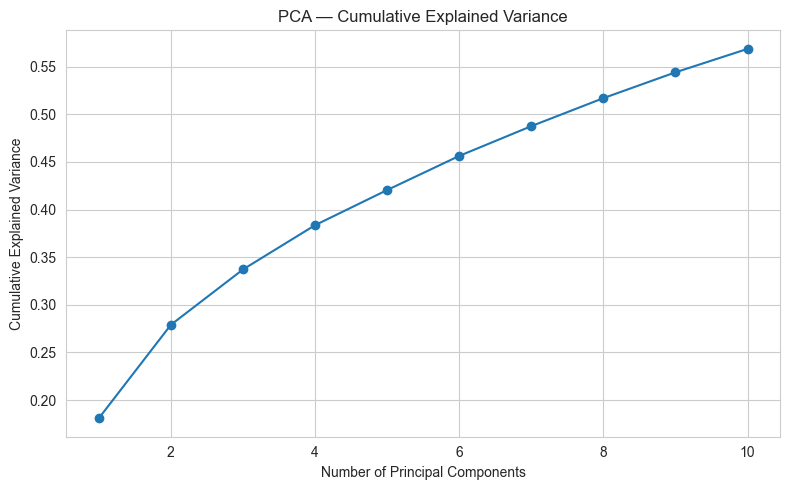

In [12]:
pca = PCA(n_components=10, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

for i, v in enumerate(explained, 1):
    print(f"PC{i}: {v*100:5.2f}% of variance")
print(f"\nCumulative variance explained by first {len(explained)} components: "
      f"{explained.sum()*100:.2f}%")

plt.figure()
plt.plot(range(1, len(explained) + 1), np.cumsum(explained), marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA ΓÇö Cumulative Explained Variance")
plt.tight_layout()
plt.show()

## 9. Discretization

`URLLength` is binned into interpretable categories ΓÇö useful both as a
reduction/preprocessing step and for a discrete view of the data later.

In [12]:
df_model["URLLength_bin"] = pd.cut(
    df_model["URLLength"],
    bins=[0, 30, 60, 100, np.inf],
    labels=["Short", "Medium", "Long", "Very Long"],
)
df_model["URLLength_bin"].value_counts()

URLLength_bin
Short        152337
Medium        67518
Long          11077
Very Long      4863
Name: count, dtype: int64

## 10. Vector and Matrix Concepts

Every row of `X_scaled` is a **feature vector**; the full table is a
**design matrix** `X` of shape `(n_samples, n_features)`.

### 10.1 A sample as a vector, and vector similarity

In [13]:
sample_vector = X_scaled.iloc[0].values
print("Sample 0 as a feature vector ΓÇö shape:", sample_vector.shape)
print("L2 norm (magnitude) of sample 0:", np.linalg.norm(sample_vector))

legit_idx = y[y == 1].index[0]
phish_idx = y[y == 0].index[0]
v_legit = X_scaled.loc[legit_idx].values
v_phish = X_scaled.loc[phish_idx].values

dot_product = np.dot(v_legit, v_phish)
cos_sim = dot_product / (np.linalg.norm(v_legit) * np.linalg.norm(v_phish))
print(f"\nDot product <legitimate, phishing> = {dot_product:.4f}")
print(f"Cosine similarity between one legitimate and one phishing sample: {cos_sim:.4f}")

Sample 0 as a feature vector ΓÇö shape: (51,)
L2 norm (magnitude) of sample 0: 5.1267425061229455

Dot product <legitimate, phishing> = 0.6410
Cosine similarity between one legitimate and one phishing sample: 0.0247


### 10.2 The design matrix and its transpose

In [14]:
X_matrix = X_scaled.values
print("Design matrix X shape (n_samples x n_features):", X_matrix.shape)
print("Transpose X.T shape (n_features x n_samples):   ", X_matrix.T.shape)

Design matrix X shape (n_samples x n_features): (235795, 51)
Transpose X.T shape (n_features x n_samples):    (51, 235795)


### 10.3 Covariance and correlation matrices

Computed manually via `Xß╡ÇX` on the centered matrix, and verified against
`numpy.cov`.

In [15]:
n_samples = X_matrix.shape[0]
X_centered = X_matrix - X_matrix.mean(axis=0)

cov_manual = (X_centered.T @ X_centered) / (n_samples - 1)
cov_numpy = np.cov(X_matrix, rowvar=False)

print("Covariance matrix shape:", cov_manual.shape)
print("Manual (X_centered.T @ X_centered)/(n-1) matches np.cov:",
      np.allclose(cov_manual, cov_numpy, atol=1e-6))

corr_matrix = X_scaled.corr()
print("Correlation matrix shape:", corr_matrix.shape)

Covariance matrix shape: (51, 51)
Manual (X_centered.T @ X_centered)/(n-1) matches np.cov: True
Correlation matrix shape: (51, 51)


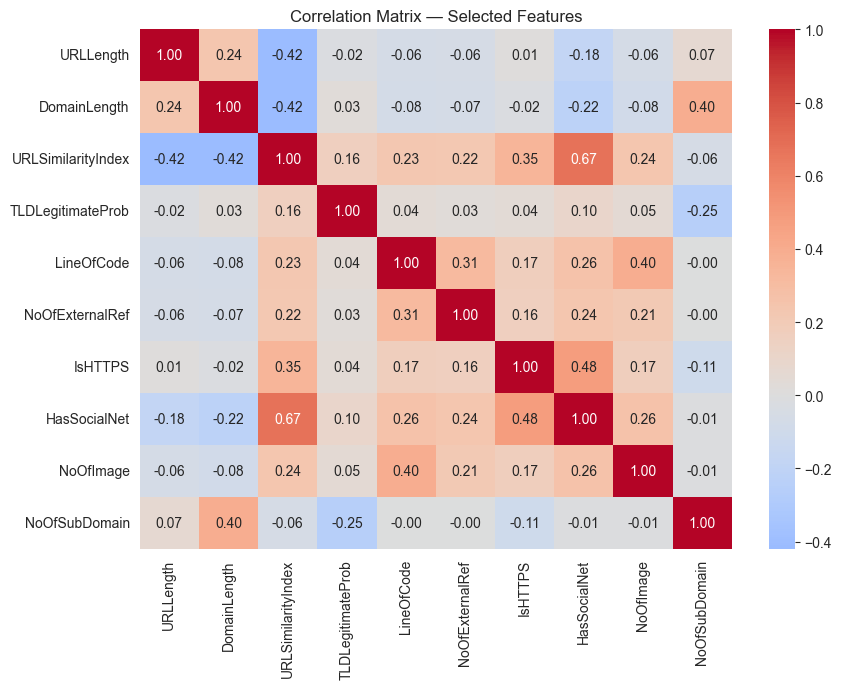

In [16]:
subset_features = ["URLLength", "DomainLength", "URLSimilarityIndex",
                    "TLDLegitimateProb", "LineOfCode", "NoOfExternalRef",
                    "IsHTTPS", "HasSocialNet", "NoOfImage", "NoOfSubDomain"]
subset_features = [f for f in subset_features if f in X_scaled.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(X_scaled[subset_features].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Correlation Matrix ΓÇö Selected Features")
plt.tight_layout()
plt.show()

In [17]:
target_corr = (df_model[numeric_cols + [target_col]]
               .corr()[target_col]
               .drop(target_col)
               .sort_values(key=abs, ascending=False))

print("Top 10 features most correlated (in magnitude) with the target label:")
target_corr.head(10)

Top 10 features most correlated (in magnitude) with the target label:


URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL   -0.533537
Name: label, dtype: float64

## 11. Exploratory Data Analysis

### 11.1 Overall summary statistics

In [18]:
df_model[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


### 11.2 Per-question EDA

Each analysis question from Section 3 is answered here with dedicated code.
Written insights for every question are consolidated in **Section 14**.

**Q1. Is the dataset balanced between phishing and legitimate URLs?**

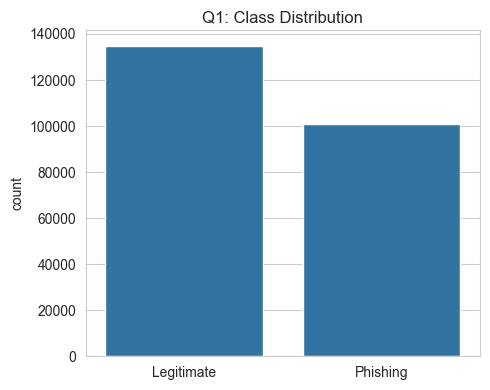

Legitimate: 134,850 (57.19%)
Phishing:   100,945 (42.81%)


In [17]:
q1_counts = df_model[target_col].value_counts().sort_index()
q1_pct = df_model[target_col].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(5, 4))
sns.countplot(x=df_model[target_col].map({1: "Legitimate", 0: "Phishing"}))
plt.title("Q1: Class Distribution")
plt.xlabel("")
plt.tight_layout()
plt.show()

print(f"Legitimate: {q1_counts[1]:,} ({q1_pct[1]:.2f}%)")
print(f"Phishing:   {q1_counts[0]:,} ({q1_pct[0]:.2f}%)")

**Q2. Is `URLLength` significantly different between phishing and legitimate URLs?**

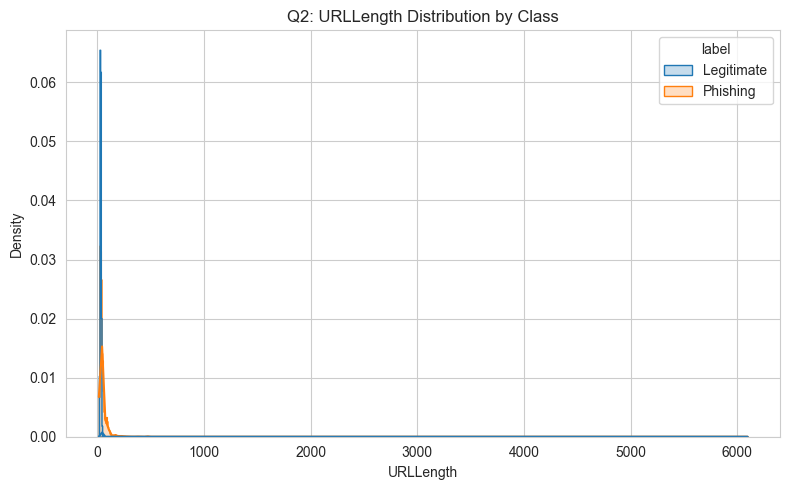

Mean URLLength ΓÇö Legitimate: 26.23, Phishing: 45.72
Welch's t-test: t = -101.046, p-value = 0


In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_model, x="URLLength",
             hue=df_model[target_col].map({1: "Legitimate", 0: "Phishing"}),
             kde=True, element="step", stat="density", common_norm=False)
plt.title("Q2: URLLength Distribution by Class")
plt.tight_layout()
plt.show()

q2_legit = df_model.loc[df_model[target_col] == 1, "URLLength"]
q2_phish = df_model.loc[df_model[target_col] == 0, "URLLength"]
q2_t, q2_p = stats.ttest_ind(q2_legit, q2_phish, equal_var=False)

print(f"Mean URLLength ΓÇö Legitimate: {q2_legit.mean():.2f}, Phishing: {q2_phish.mean():.2f}")
print(f"Welch's t-test: t = {q2_t:.3f}, p-value = {q2_p:.4g}")

**Q3. Do phishing URLs use HTTPS less often than legitimate URLs?**

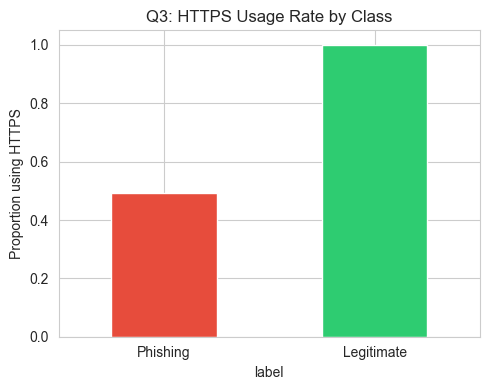

label
Phishing      0.492238
Legitimate    1.000000
Name: IsHTTPS, dtype: float64

Chi-square test: chi2 = 87486.79, p-value = 0


In [19]:
q3_rates = df_model.groupby(target_col)["IsHTTPS"].mean()
q3_rates.index = q3_rates.index.map({0: "Phishing", 1: "Legitimate"})

plt.figure(figsize=(5, 4))
q3_rates.plot(kind="bar", color=["#e74c3c", "#2ecc71"])
plt.title("Q3: HTTPS Usage Rate by Class")
plt.ylabel("Proportion using HTTPS")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

q3_chi2, q3_p, _, _ = stats.chi2_contingency(
    pd.crosstab(df_model["IsHTTPS"], df_model[target_col])
)
print(q3_rates)
print(f"\nChi-square test: chi2 = {q3_chi2:.2f}, p-value = {q3_p:.4g}")

**Q4. Does the number of subdomains relate to phishing likelihood?**

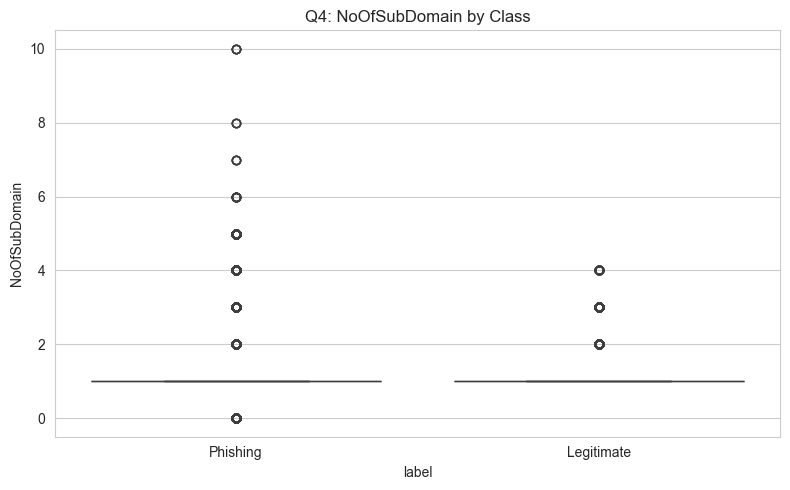

Mean NoOfSubDomain ΓÇö Legitimate: 1.162, Phishing: 1.169
Correlation with label: -0.0060


In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_model, x=target_col, y="NoOfSubDomain")
plt.xticks([0, 1], ["Phishing", "Legitimate"])
plt.title("Q4: NoOfSubDomain by Class")
plt.tight_layout()
plt.show()

q4_legit = df_model.loc[df_model[target_col] == 1, "NoOfSubDomain"]
q4_phish = df_model.loc[df_model[target_col] == 0, "NoOfSubDomain"]
print(f"Mean NoOfSubDomain ΓÇö Legitimate: {q4_legit.mean():.3f}, Phishing: {q4_phish.mean():.3f}")
print(f"Correlation with label: {df_model['NoOfSubDomain'].corr(df_model[target_col]):.4f}")

**Q5. How does `TLDLegitimateProb` differ between classes, and how well does it separate them alone?**

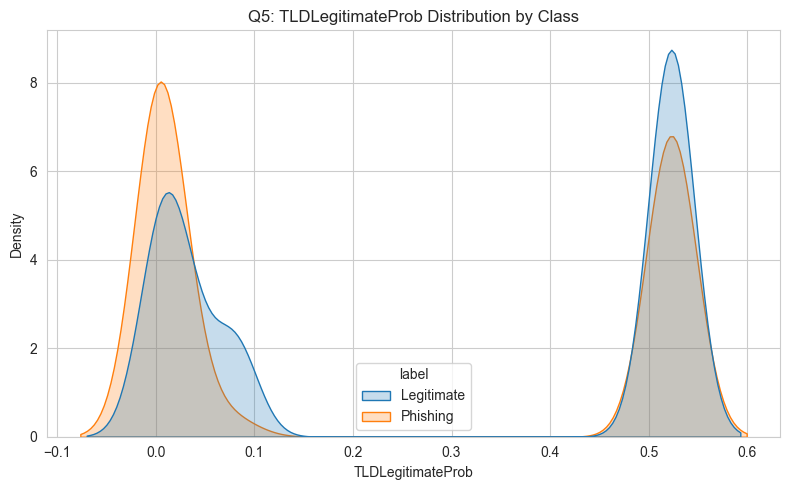

Mean TLDLegitimateProb ΓÇö Legitimate: 0.2816, Phishing: 0.2321
Naive single-threshold (median split) classification accuracy: 59.47%


In [21]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_model, x="TLDLegitimateProb",
            hue=df_model[target_col].map({1: "Legitimate", 0: "Phishing"}), fill=True, common_norm=False)
plt.title("Q5: TLDLegitimateProb Distribution by Class")
plt.tight_layout()
plt.show()

q5_legit = df_model.loc[df_model[target_col] == 1, "TLDLegitimateProb"]
q5_phish = df_model.loc[df_model[target_col] == 0, "TLDLegitimateProb"]
q5_threshold = df_model["TLDLegitimateProb"].median()
q5_naive_acc = ((df_model["TLDLegitimateProb"] >= q5_threshold).astype(int) == df_model[target_col]).mean()

print(f"Mean TLDLegitimateProb ΓÇö Legitimate: {q5_legit.mean():.4f}, Phishing: {q5_phish.mean():.4f}")
print(f"Naive single-threshold (median split) classification accuracy: {q5_naive_acc*100:.2f}%")

**Q6. Are phishing pages less likely to have a title matching their URL/domain?**

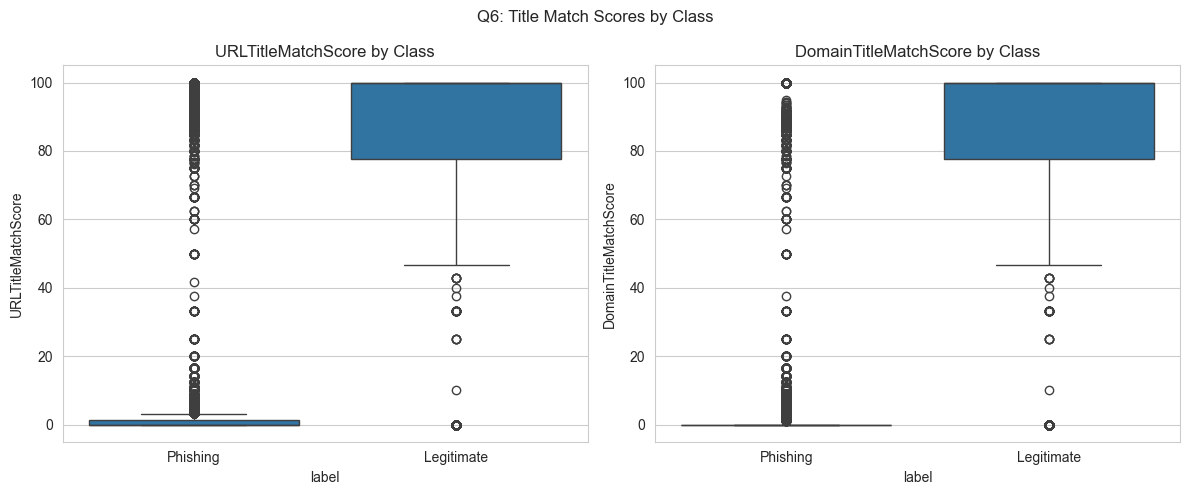

URLTitleMatchScore ΓÇö Legitimate mean: 75.27, Phishing mean: 21.20
DomainTitleMatchScore ΓÇö Legitimate mean: 75.27, Phishing mean: 16.55


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_model, x=target_col, y="URLTitleMatchScore", ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Phishing", "Legitimate"])
axes[0].set_title("URLTitleMatchScore by Class")

sns.boxplot(data=df_model, x=target_col, y="DomainTitleMatchScore", ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Phishing", "Legitimate"])
axes[1].set_title("DomainTitleMatchScore by Class")
plt.suptitle("Q6: Title Match Scores by Class")
plt.tight_layout()
plt.show()

for col in ["URLTitleMatchScore", "DomainTitleMatchScore"]:
    l = df_model.loc[df_model[target_col] == 1, col].mean()
    p = df_model.loc[df_model[target_col] == 0, col].mean()
    print(f"{col} ΓÇö Legitimate mean: {l:.2f}, Phishing mean: {p:.2f}")

**Q7. Are financial keywords (`Bank`, `Pay`, `Crypto`) more common on phishing pages?**

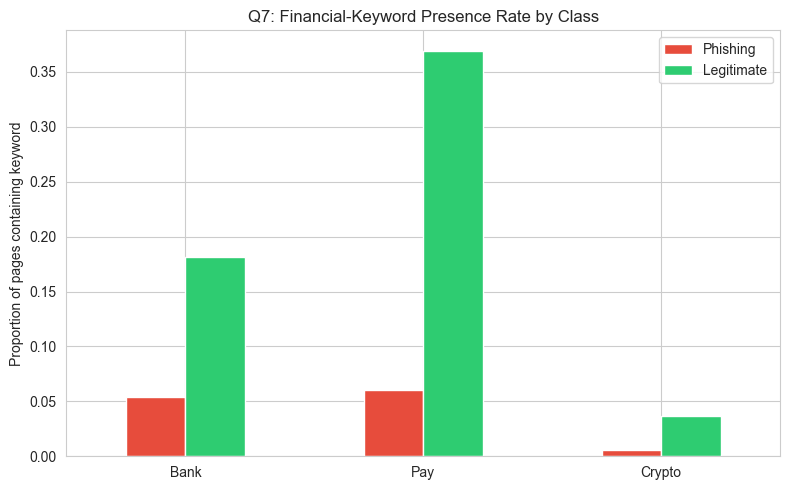

,Phishing,Legitimate
Bank,0.054346,0.181542
Pay,0.060191,0.369366
Crypto,0.006043,0.036522


In [23]:
q7_cols = ["Bank", "Pay", "Crypto"]
q7_rates = df_model.groupby(target_col)[q7_cols].mean().T
q7_rates.columns = ["Phishing", "Legitimate"]

q7_rates.plot(kind="bar", figsize=(8, 5), color=["#e74c3c", "#2ecc71"])
plt.title("Q7: Financial-Keyword Presence Rate by Class")
plt.ylabel("Proportion of pages containing keyword")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

q7_rates

**Q8. Do phishing pages contain less content richness (`NoOfImage`, `NoOfCSS`, `NoOfJS`) than legitimate ones?**

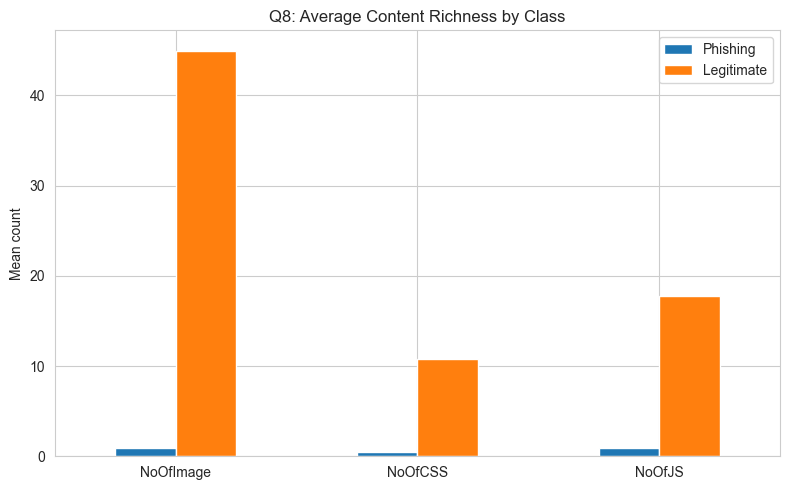

,Phishing,Legitimate
NoOfImage,0.866492,44.946600
NoOfCSS,0.439616,10.744820
NoOfJS,0.890336,17.732532


In [24]:
q8_cols = ["NoOfImage", "NoOfCSS", "NoOfJS"]
q8_means = df_model.groupby(target_col)[q8_cols].mean().T
q8_means.columns = ["Phishing", "Legitimate"]

q8_means.plot(kind="bar", figsize=(8, 5))
plt.title("Q8: Average Content Richness by Class")
plt.ylabel("Mean count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

q8_means

**Q9. Is having a favicon associated with legitimacy?**

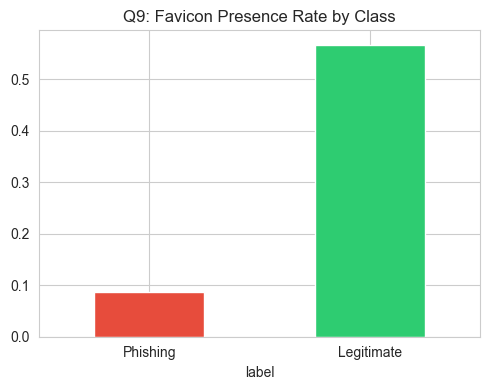

label
Phishing      0.087572
Legitimate    0.567023
Name: HasFavicon, dtype: float64


In [25]:
q9_rates = df_model.groupby(target_col)["HasFavicon"].mean()
q9_rates.index = q9_rates.index.map({0: "Phishing", 1: "Legitimate"})

plt.figure(figsize=(5, 4))
q9_rates.plot(kind="bar", color=["#e74c3c", "#2ecc71"])
plt.title("Q9: Favicon Presence Rate by Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(q9_rates)

**Q10. Does linking to social media correlate with legitimacy?**

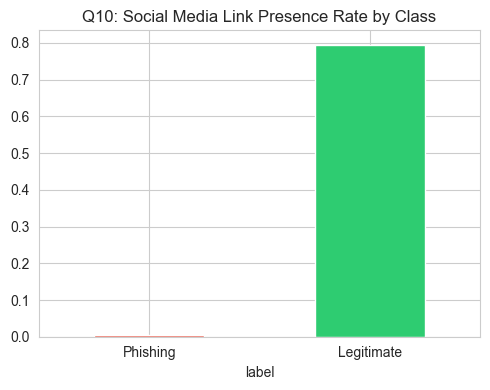

label
Phishing      0.005062
Legitimate    0.794557
Name: HasSocialNet, dtype: float64


In [26]:
q10_rates = df_model.groupby(target_col)["HasSocialNet"].mean()
q10_rates.index = q10_rates.index.map({0: "Phishing", 1: "Legitimate"})

plt.figure(figsize=(5, 4))
q10_rates.plot(kind="bar", color=["#e74c3c", "#2ecc71"])
plt.title("Q10: Social Media Link Presence Rate by Class")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(q10_rates)

**Q11. Are phishing URLs more likely to use obfuscation?**

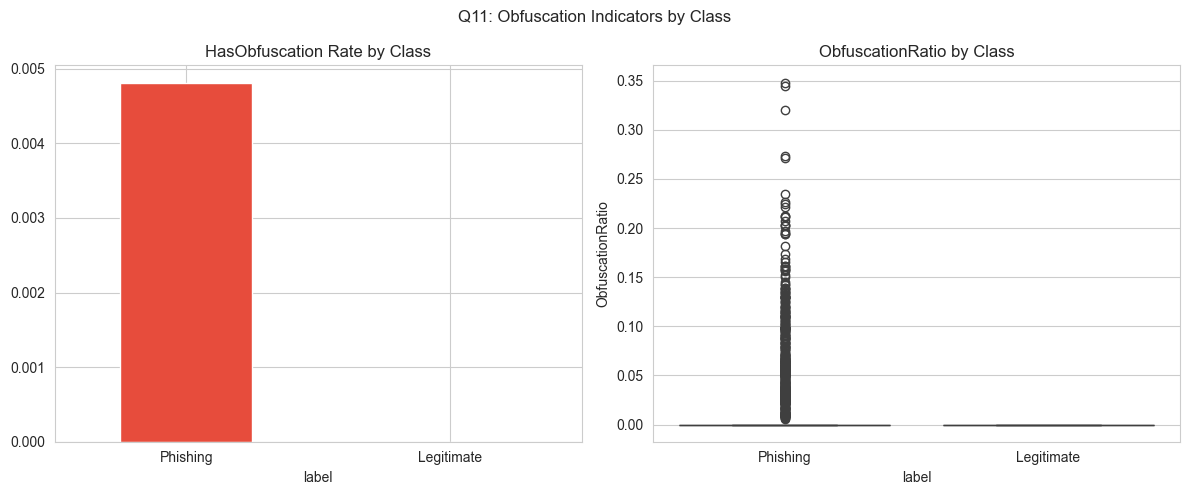

label
Phishing      0.004805
Legitimate    0.000000
Name: HasObfuscation, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

q11_rates = df_model.groupby(target_col)["HasObfuscation"].mean()
q11_rates.index = q11_rates.index.map({0: "Phishing", 1: "Legitimate"})
q11_rates.plot(kind="bar", ax=axes[0], color=["#e74c3c", "#2ecc71"])
axes[0].set_title("HasObfuscation Rate by Class")
axes[0].tick_params(axis="x", rotation=0)

sns.boxplot(data=df_model, x=target_col, y="ObfuscationRatio", ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Phishing", "Legitimate"])
axes[1].set_title("ObfuscationRatio by Class")

plt.suptitle("Q11: Obfuscation Indicators by Class")
plt.tight_layout()
plt.show()

print(q11_rates)

**Q12. Is submitting form data to an external domain a strong phishing indicator?**

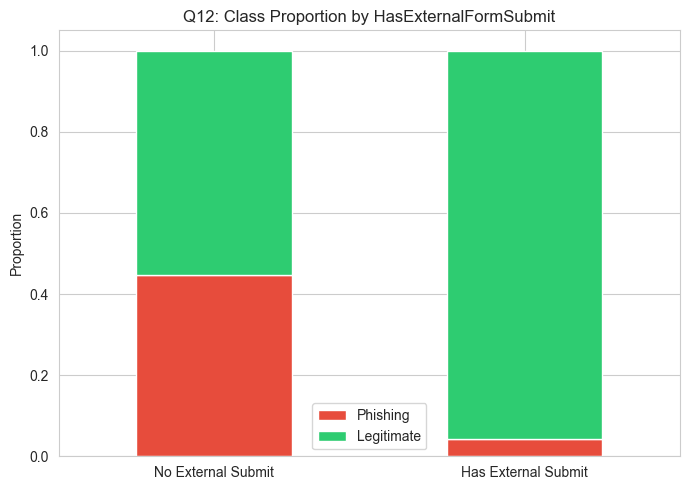

                     Phishing  Legitimate
No External Submit   0.445891    0.554109
Has External Submit  0.041554    0.958446

Chi-square test: chi2 = 6619.68, p-value = 0


In [28]:
q12_crosstab = pd.crosstab(df_model["HasExternalFormSubmit"], df_model[target_col], normalize="index")
q12_crosstab.columns = ["Phishing", "Legitimate"]
q12_crosstab.index = ["No External Submit", "Has External Submit"]

q12_crosstab.plot(kind="bar", stacked=True, figsize=(7, 5), color=["#e74c3c", "#2ecc71"])
plt.title("Q12: Class Proportion by HasExternalFormSubmit")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

q12_chi2, q12_p, _, _ = stats.chi2_contingency(
    pd.crosstab(df_model["HasExternalFormSubmit"], df_model[target_col])
)
print(q12_crosstab)
print(f"\nChi-square test: chi2 = {q12_chi2:.2f}, p-value = {q12_p:.4g}")

**Q13. How does `URLSimilarityIndex` differ between classes, and could it alone act as a phishing indicator?**

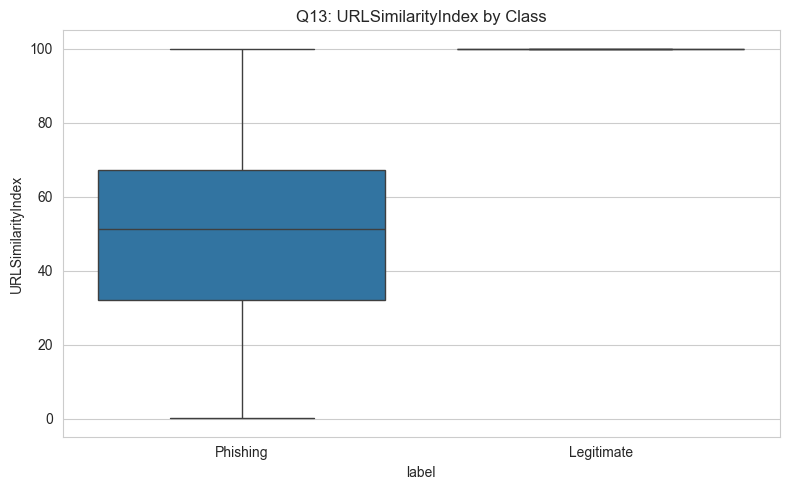

Median-threshold naive classification accuracy using URLSimilarityIndex alone: 99.67%


In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_model, x=target_col, y="URLSimilarityIndex")
plt.xticks([0, 1], ["Phishing", "Legitimate"])
plt.title("Q13: URLSimilarityIndex by Class")
plt.tight_layout()
plt.show()

q13_threshold = df_model["URLSimilarityIndex"].median()
q13_naive_acc = ((df_model["URLSimilarityIndex"] >= q13_threshold).astype(int) == df_model[target_col]).mean()
print(f"Median-threshold naive classification accuracy using URLSimilarityIndex alone: {q13_naive_acc*100:.2f}%")

**Q14. Are certain TLDs disproportionately used for phishing?**

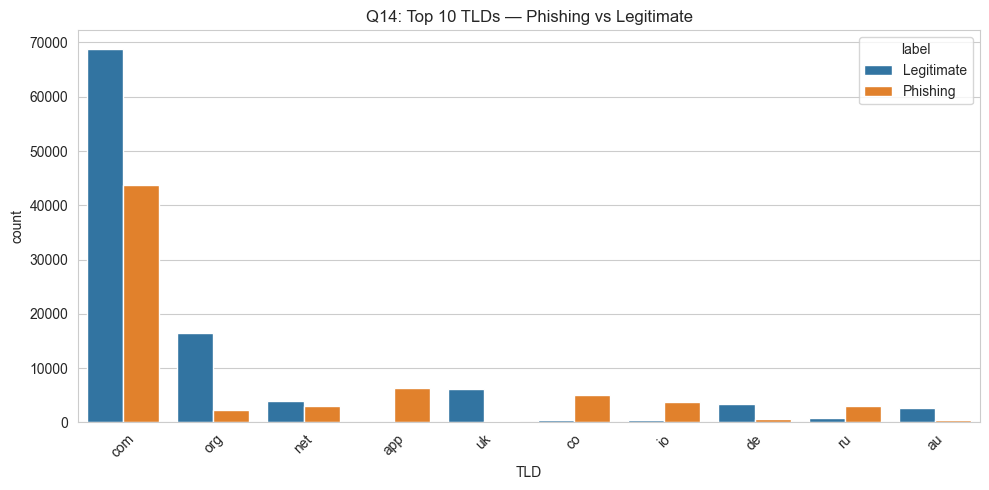

Phishing rate within each of the top 10 TLDs:
TLD
app    97.85
co     91.55
io     89.72
ru     76.98
net    43.67
com    38.89
de     17.17
au     12.52
org    12.07
uk      5.04
Name: label, dtype: float64


In [30]:
top_tlds = df_model["TLD"].value_counts().head(10).index
tld_subset = df_model[df_model["TLD"].isin(top_tlds)]

plt.figure(figsize=(10, 5))
sns.countplot(data=tld_subset, x="TLD",
              hue=tld_subset[target_col].map({1: "Legitimate", 0: "Phishing"}),
              order=top_tlds)
plt.title("Q14: Top 10 TLDs ΓÇö Phishing vs Legitimate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

q14_phish_rate_by_tld = (1 - df_model.groupby("TLD")[target_col].mean()).loc[top_tlds].sort_values(ascending=False)
print("Phishing rate within each of the top 10 TLDs:")
print((q14_phish_rate_by_tld * 100).round(2))

**Q15. Which features are most correlated with each other, and how much variance do a few principal components capture?**

In [31]:
corr_abs = X_scaled[numeric_cols].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .sort_values("abs_corr", ascending=False)
)

print("Top 10 most correlated feature pairs:")
print(high_corr_pairs.head(10).to_string(index=False))
print(f"\nFirst {len(explained)} principal components explain {explained.sum()*100:.2f}% of total variance "
      f"(see Section 8 for the full PCA)." )

Top 10 most correlated feature pairs:
            feature_1                  feature_2  abs_corr
DomainTitleMatchScore         URLTitleMatchScore  0.961008
            URLLength           NoOfLettersInURL  0.956047
            URLLength            NoOfDegitsInURL  0.835809
      NoOfDegitsInURL            NoOfEqualsInURL  0.806024
       HasObfuscation           ObfuscationRatio  0.798791
   NoOfObfuscatedChar         NoOfAmpersandInURL  0.786451
      NoOfEqualsInURL NoOfOtherSpecialCharsInURL  0.784654
            URLLength NoOfOtherSpecialCharsInURL  0.782582
      NoOfDegitsInURL NoOfOtherSpecialCharsInURL  0.767477
   NoOfObfuscatedChar            NoOfEqualsInURL  0.754543

First 10 principal components explain 56.87% of total variance (see Section 8 for the full PCA).


## 12. Random Variables and Probability Distributions

### 12.1 A continuous random variable: `URLLength`

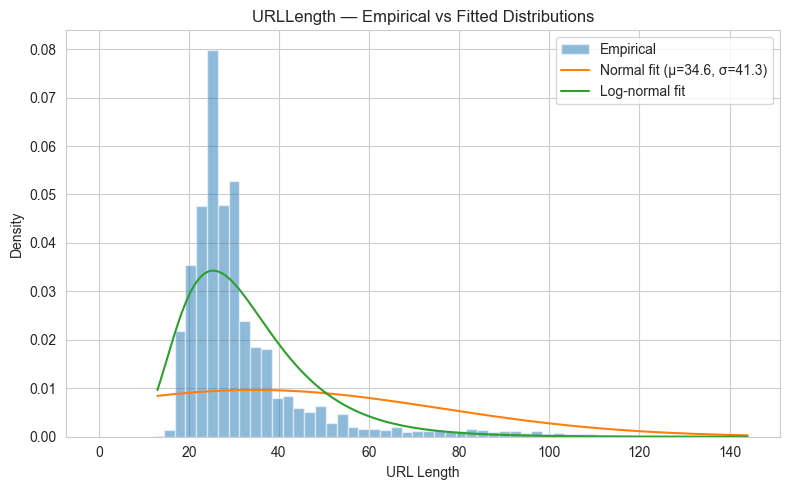

KS test vs Normal    : statistic=0.3327, p-value=0
KS test vs Log-normal: statistic=0.1591, p-value=0


In [13]:
data_urllen = df_model["URLLength"].dropna().values

mu, sigma = stats.norm.fit(data_urllen)
ln_shape, ln_loc, ln_scale = stats.lognorm.fit(data_urllen, floc=0)

x_vals = np.linspace(data_urllen.min(), np.percentile(data_urllen, 99), 200)

plt.figure(figsize=(8, 5))
plt.hist(data_urllen, bins=60, density=True, alpha=0.5, label="Empirical",
         range=(0, np.percentile(data_urllen, 99)))
plt.plot(x_vals, stats.norm.pdf(x_vals, mu, sigma),
         label=f"Normal fit (╬╝={mu:.1f}, ╧â={sigma:.1f})")
plt.plot(x_vals, stats.lognorm.pdf(x_vals, ln_shape, ln_loc, ln_scale),
         label="Log-normal fit")
plt.title("URLLength ΓÇö Empirical vs Fitted Distributions")
plt.xlabel("URL Length")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

norm_dist = stats.norm(loc=mu, scale=sigma)
lognorm_dist = stats.lognorm(s=ln_shape, loc=ln_loc, scale=ln_scale)

ks_norm = stats.kstest(data_urllen, norm_dist.cdf)
ks_lognorm = stats.kstest(data_urllen, lognorm_dist.cdf)
print(f"KS test vs Normal    : statistic={ks_norm.statistic:.4f}, p-value={ks_norm.pvalue:.4g}")
print(f"KS test vs Log-normal: statistic={ks_lognorm.statistic:.4f}, p-value={ks_lognorm.pvalue:.4g}")

### 12.2 A discrete random variable: `NoOfSubDomain`

Modeled as a Poisson-distributed count variable and compared to the
empirical PMF.

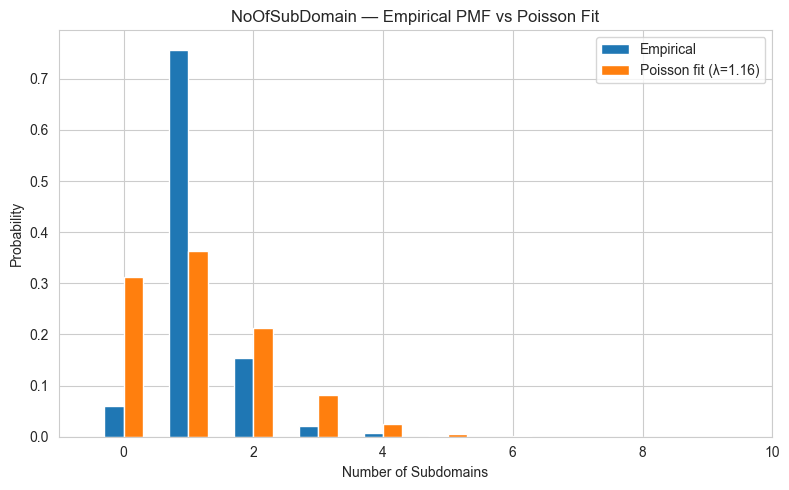

In [14]:
data_subdom = df_model["NoOfSubDomain"].dropna()
lam = data_subdom.mean()

k_vals = np.arange(0, data_subdom.max() + 1)
empirical_pmf = data_subdom.value_counts(normalize=True).sort_index()
poisson_pmf = stats.poisson.pmf(k_vals, lam)

plt.figure(figsize=(8, 5))
plt.bar(empirical_pmf.index - 0.15, empirical_pmf.values, width=0.3, label="Empirical")
plt.bar(k_vals + 0.15, poisson_pmf, width=0.3, label=f"Poisson fit (╬╗={lam:.2f})")
plt.xlim(-1, 10)
plt.title("NoOfSubDomain ΓÇö Empirical PMF vs Poisson Fit")
plt.xlabel("Number of Subdomains")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Sampling and the Central Limit Theorem

`URLLength` (all deduplicated rows) is treated as the population. We
repeatedly draw random samples of increasing size `n`, compute the sample
mean each time, and observe the sampling distribution of the mean.

Population mean: 34.57, Population std: 41.31, N = 235795


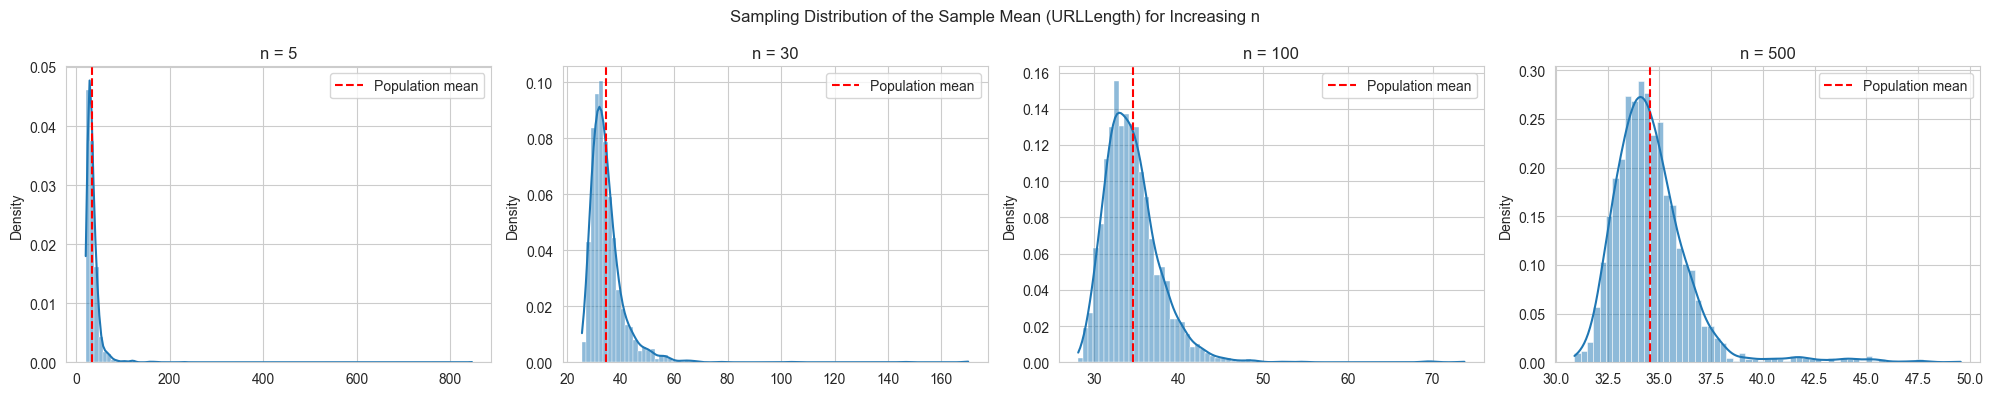

In [15]:
population = df_model["URLLength"].dropna().values
pop_mean, pop_std = population.mean(), population.std()
print(f"Population mean: {pop_mean:.2f}, Population std: {pop_std:.2f}, N = {len(population)}")

sample_sizes = [5, 30, 100, 500]
n_samples_drawn = 2000
rng = np.random.default_rng(RANDOM_STATE)

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(20, 4))
sampling_results = {}
for ax, n in zip(axes, sample_sizes):
    sample_means = np.array([rng.choice(population, size=n, replace=True).mean()
                              for _ in range(n_samples_drawn)])
    sampling_results[n] = sample_means
    sns.histplot(sample_means, kde=True, ax=ax, stat="density")
    ax.axvline(pop_mean, color="red", linestyle="--", label="Population mean")
    ax.set_title(f"n = {n}")
    ax.legend()

plt.suptitle("Sampling Distribution of the Sample Mean (URLLength) for Increasing n")
plt.tight_layout()
plt.show()

    n |   mean of sample means |  std of sample means |  predicted SE = ╧â/ΓêÜn
------------------------------------------------------------------------------
    5 |                 35.012 |               22.782 |               18.476
   30 |                 34.822 |                7.876 |                7.543
  100 |                 34.492 |                3.431 |                4.131
  500 |                 34.618 |                1.966 |                1.848


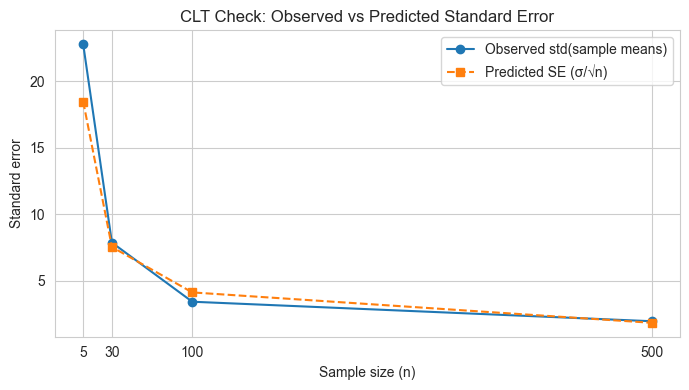

,n,mean_of_sample_means,std_of_sample_means,predicted_se
0,5,35.012200,22.781857,18.476212
1,30,34.822050,7.876279,7.542882
2,100,34.492355,3.431416,4.131407
3,500,34.618104,1.965519,1.847621


In [16]:
rows = []
print(f"{'n':>5} | {'mean of sample means':>22} | {'std of sample means':>20} | {'predicted SE = ╧â/ΓêÜn':>20}")
print("-" * 78)
for n in sample_sizes:
    sm = sampling_results[n]
    predicted_se = pop_std / np.sqrt(n)
    mean_sm = np.mean(sm)
    std_sm = np.std(sm)
    rows.append({
        "n": n,
        "mean_of_sample_means": mean_sm,
        "std_of_sample_means": std_sm,
        "predicted_se": predicted_se,
    })
    print(f"{n:>5} | {mean_sm:>22.3f} | {std_sm:>20.3f} | {predicted_se:>20.3f}")

clt_df = pd.DataFrame(rows)
plt.figure(figsize=(7, 4))
plt.plot(clt_df["n"], clt_df["std_of_sample_means"], marker="o", label="Observed std(sample means)")
plt.plot(clt_df["n"], clt_df["predicted_se"], marker="s", linestyle="--", label="Predicted SE (╧â/ΓêÜn)")
plt.title("CLT Check: Observed vs Predicted Standard Error")
plt.xlabel("Sample size (n)")
plt.ylabel("Standard error")
plt.xticks(clt_df["n"])
plt.legend()
plt.tight_layout()
plt.show()

clt_df

## 14. Interpretation of Results ΓÇö Insights per Analysis Question

**Q1. Is the dataset balanced?**
> *Insight:* The dataset is moderately imbalanced: 57.19% legitimate (134,850) and 42.81% phishing (100,945). This is not extreme, so baseline modeling is still feasible, but metrics beyond plain accuracy (such as precision/recall/F1) should be emphasized to avoid bias toward the majority class.

**Q2. Is `URLLength` significantly different between classes?**
> *Insight:* Phishing URLs are substantially longer on average (45.72) than legitimate URLs (26.23). Welch's t-test returns a very large magnitude statistic (t = -101.046) with p-value effectively 0, indicating a statistically significant difference.

**Q3. Do phishing URLs use HTTPS less often?**
> *Insight:* HTTPS usage is 100.0% for legitimate URLs versus 49.22% for phishing URLs, a very large separation. The chi-square test is highly significant (chi2 = 87,486.79, p-value ~ 0), so HTTPS presence is strongly associated with legitimacy in this dataset.

**Q4. Does `NoOfSubDomain` relate to phishing likelihood?**
> *Insight:* Mean subdomain counts are almost identical (legitimate 1.162 vs phishing 1.169). The correlation with label is -0.0060, which is essentially zero, so this feature has negligible standalone signal here.

**Q5. How does `TLDLegitimateProb` differ, and how well does it separate the classes alone?**
> *Insight:* Legitimate URLs have a higher mean `TLDLegitimateProb` (0.2816) than phishing URLs (0.2321), consistent with expectation. However, the naive median-threshold accuracy is 59.47%, so this feature is only weak-to-moderate when used alone.

**Q6. Are phishing pages less likely to have a matching title?**
> *Insight:* Both title-match features show large gaps: `URLTitleMatchScore` is 75.27 (legitimate) vs 21.20 (phishing), and `DomainTitleMatchScore` is 75.27 vs 16.55. This indicates that phishing pages much more often have poor semantic consistency between URL/domain and page title.

**Q7. Are financial keywords more common on phishing pages?**
> *Insight:* In this dataset, the opposite pattern appears: legitimate pages show higher rates for all three keywords (`Bank`: 18.15% vs 5.43%, `Pay`: 36.94% vs 6.02%, `Crypto`: 3.65% vs 0.60%). This suggests these keywords are not phishing-specific by themselves and likely reflect many benign financial/service sites.

**Q8. Do phishing pages contain less content richness?**
> *Insight:* Legitimate pages have far richer content by mean counts: `NoOfImage` 44.95 vs 0.87, `NoOfCSS` 10.74 vs 0.44, `NoOfJS` 17.73 vs 0.89 (legitimate vs phishing). This supports the idea that many phishing pages in this corpus are simpler or thinner pages.

**Q9. Is having a favicon associated with legitimacy?**
> *Insight:* Favicon presence is much more common in legitimate pages (56.70%) than phishing pages (8.76%). So `HasFavicon` is a useful supportive legitimacy indicator, though not sufficient alone.

**Q10. Does linking to social media correlate with legitimacy?**
> *Insight:* Social links are present in 79.46% of legitimate pages but only 0.51% of phishing pages. This is one of the strongest separations observed and strongly correlates with legitimacy.

**Q11. Are phishing URLs more likely to use obfuscation?**
> *Insight:* `HasObfuscation` is nonzero for phishing (0.48%) and zero for legitimate (0.00%), so obfuscation events are concentrated in phishing. The `ObfuscationRatio` distribution also shows phishing outliers while legitimate values remain near zero, reinforcing this direction despite low absolute prevalence.

**Q12. Is external form submission a strong phishing indicator?**
> *Insight:* The association is statistically strong (chi2 = 6,619.68, p-value ~ 0), but direction is counterintuitive in this dataset: among pages with external submit, only 4.16% are phishing and 95.84% are legitimate. This indicates the feature is important but should be interpreted contextually rather than treated as a universal phishing flag.

**Q13. How does `URLSimilarityIndex` differ, and can it alone classify well?**
> *Insight:* `URLSimilarityIndex` is extremely discriminative here: a naive median threshold yields 99.67% accuracy. That suggests near-complete class separation in this dataset, and this feature alone carries very high predictive power.

**Q14. Are certain TLDs disproportionately used for phishing?**
> *Insight:* Yes, phishing concentration differs sharply by TLD among the top 10. Highest phishing rates are `app` (97.85%), `co` (91.55%), and `io` (89.72%), while the lowest are `uk` (5.04%), `org` (12.07%), and `au` (12.52%).

**Q15. Which features are most redundant, and how much variance do a few components explain?**
> *Insight:* The strongest redundancy is between `DomainTitleMatchScore` and `URLTitleMatchScore` (abs corr = 0.961), followed by `URLLength` with `NoOfLettersInURL` (0.956). The first 10 principal components explain 56.87% of total variance, indicating meaningful dimensionality compression but also that information is spread across many features.

## 15. Conclusion

*(After completing the insights in Section 14, write 3ΓÇô5 sentences here
summarizing the overall picture: which 2ΓÇô3 features are the strongest
individual phishing indicators, whether the dataset is suitable for direct
modelling, and what the CLT demonstration in Section 13 confirmed about the
sampling distribution of the mean.)*
